# Exploring LoRA Rank in an MLP on MNIST

Train an MLP baseline, then adapt its middle hidden layer on the same MNIST dataset to explore accuracy across LoRA ranks. This supplementary experiment corresponds to [report Sections 3.2 and 4.4 and Figure 5](AML_project_report.pdf). See the [README](README.md) for project context and archive limitations.


## Setup

The code uses CPU. The install cell adds loralib; the other dependencies listed in the [README](README.md#mnist--mlp) must already be available. Run the cells in order.


In [ ]:
!pip install loralib

## Load and inspect MNIST

The CSV paths are specified below. Each row should contain a label followed by 784 pixel values; pixels are converted to float32 without normalization.

The original CSV header format is undocumented. `pd.read_csv()` infers a header, so headerless files require explicit handling to avoid losing the first sample.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import loralib as lora

In [ ]:
train = pd.read_csv('sample_data/mnist_train_small.csv')
test = pd.read_csv('sample_data/mnist_test.csv')

label: 5


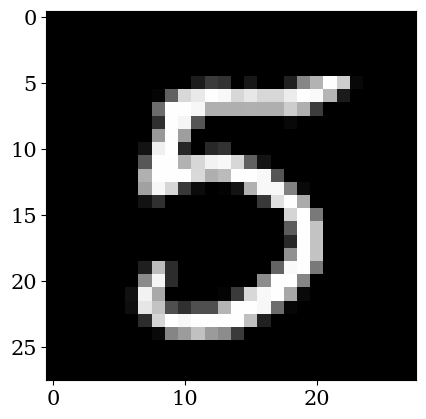

In [ ]:
print('label:', train.iloc[0, 0])
plt.imshow(train.iloc[0, 1:].values.reshape(28, 28), cmap='gray')
plt.show()

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class TrainDataset(Dataset):
  def __init__(self, data):
    self.data = data
  def __len__(self):
    return len(self.data)
  def __getitem__(self, idx):
    x = self.data.iloc[idx, 1:].values.reshape(1, 28, 28)
    y = self.data.iloc[idx, 0]
    return x, y

class TestDataset(Dataset):
  def __init__(self, data):
    self.data = data
  def __len__(self):
    return len(self.data)
  def __getitem__(self, idx):
    x = self.data.iloc[idx, 1:].values.reshape(1, 28, 28)
    y = self.data.iloc[idx, 0]
    return x, y

In [ ]:
train_set = TrainDataset(train)
test_set = TestDataset(test)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

## Train and evaluate the baseline MLP

| Setting | Value in the retained code |
|---|---|
| Architecture | 784 → 100 → 100 → 10; ReLU hidden activations |
| Parameters | 89,610 |
| Optimizer | Adam, learning rate 0.001 |
| Batch size | 128 |
| Baseline training | 1 epoch |
| Adapter training | 1 additional epoch per rank |
| Evaluation | Test classification accuracy (%) |

Save the baseline checkpoint and record its accuracy before adaptation. The training loop runs once even though its printed epoch label says `[1/10]`.


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = 'cpu'
print(device)

cpu


In [ ]:
class MLP(nn.Module):
  def __init__(self):
    super(MLP, self).__init__()
    self.fc1 = nn.Linear(784, 100)
    self.fc2 = nn.Linear(100, 100)
    self.fc3 = nn.Linear(100, 10)
  def forward(self, x):
    x = x.view(-1, 784)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

In [ ]:
model = MLP().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [ ]:
# print the model
print(model)
# print the number of total parameters
print('Total:', sum(p.numel() for p in model.parameters()))
# print the number of trainable parameters
print('Trainable:', sum(p.numel() for p in model.parameters() if p.requires_grad))

MLP(
  (fc1): Linear(in_features=784, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=100, bias=True)
  (fc3): Linear(in_features=100, out_features=10, bias=True)
)
Total: 89610
Trainable: 89610


In [ ]:
# train the model and save the final params
for epoch in range(1):
  for i, (x, y) in enumerate(train_loader):
    x = x.to(device)
    x = x.type(torch.float32)
    y = y.to(device)

    optimizer.zero_grad()
    output = model(x)
    loss = criterion(output, y)
    loss.backward()
    optimizer.step()

  print('Epoch [{}/{}], Loss: {:.4f}'.format(epoch+1, 10, loss.item()))
torch.save(model.state_dict(), 'model.pth')

Epoch [1/10], Loss: 0.1703


In [ ]:
# test the model
model.eval()
with torch.no_grad():
  correct = 0
  total = 0
  for i, (x, y) in enumerate(test_loader):
    x = x.to(device)
    x = x.type(torch.float32)
    y = y.to(device)
    output = model(x)
    _, predicted = torch.max(output.data, 1)
    total += y.size(0)
    correct += (predicted == y).sum().item()
print(f'Accuracy: {100 * correct / total:.2f}%')

Accuracy: 91.86%


## Apply LoRA to the middle layer

Only adapters in the 100 × 100 middle layer are trained: rank r adds 200r trainable parameters. The printed “Compression ratio” divides this count by the baseline's 89,610 parameters; it is not an inference model-size reduction.

The retained function copies weights but leaves fresh biases, and its `.data` assignments share storage with the baseline. These initialization details limit the rank comparison.


In [ ]:
def apply_lora(model, rank):
  if rank == 0:
    rank = 1

  model_lora = MLP()
  model_lora.fc1.weight.data = model.fc1.weight.data
  model_lora.fc2 = lora.Linear(100, 100, r=rank)
  model_lora.fc2.weight.data = model.fc2.weight.data
  model_lora.fc3.weight.data = model.fc3.weight.data
  lora.mark_only_lora_as_trainable(model_lora)

  # print the model
  # print(model_lora)
  # print the number of total parameters
  print('Total:', sum(p.numel() for p in model.parameters()))
  # print the number of trainable parameters
  Trainable = sum(p.numel() for p in model_lora.parameters() if p.requires_grad)
  print('Trainable:', Trainable)
  # calculate compression ratio
  compression_ratio = sum(p.numel() for p in model_lora.parameters() if p.requires_grad) / sum(p.numel() for p in model.parameters())
  print(f'Compression ratio: {compression_ratio:.5f}')

  optimizer = torch.optim.Adam(model_lora.parameters(), lr=0.001)
  criterion = nn.CrossEntropyLoss()

  # train the model and save the final params
  for epoch in range(1):
    for i, (x, y) in enumerate(train_loader):
      x = x.to(device)
      x = x.type(torch.float32)
      y = y.to(device)

      optimizer.zero_grad()
      output = model_lora(x)
      loss = criterion(output, y)
      loss.backward()
      optimizer.step()

    # print('Epoch [{}/{}], Loss: {:.4f}'.format(epoch+1, 10, loss.item()))

  # test the model
  model_lora.eval()
  # with model_lora.no_grad():
  correct = 0
  total = 0
  for i, (x, y) in enumerate(test_loader):
    x = x.to(device)
    x = x.type(torch.float32)
    y = y.to(device)
    output = model_lora(x)
    _, predicted = torch.max(output.data, 1)
    total += y.size(0)
    correct += (predicted == y).sum().item()
  acc = 100 * correct / total
  return acc, Trainable

## Compare adapter ranks

The effective ranks are 1, 4, 8, …, 100. The function converts the first loop value, 0, to rank 1, despite the printed `Rank: 0`. Subsequent ranks increase by four, not by doubling.


In [ ]:
accuracy = []
Trainable = []
# rank increase by double
for rank in range(0, 101, 4):
  result = apply_lora(model, rank)
  accuracy.append(result[0])
  Trainable.append(result[1])
  print(f'Rank: {rank}, Accuracy: {accuracy[-1]:.2f}%')
  print('---------------------------------------------------------------------')

Total: 89610
Trainable: 200
Compression ratio: 0.00223
Rank: 0, Accuracy: 92.91%
---------------------------------------------------------------------
Total: 89610
Trainable: 800
Compression ratio: 0.00893
Rank: 4, Accuracy: 93.03%
---------------------------------------------------------------------
Total: 89610
Trainable: 1600
Compression ratio: 0.01786
Rank: 8, Accuracy: 93.06%
---------------------------------------------------------------------
Total: 89610
Trainable: 2400
Compression ratio: 0.02678
Rank: 12, Accuracy: 93.10%
---------------------------------------------------------------------
Total: 89610
Trainable: 3200
Compression ratio: 0.03571
Rank: 16, Accuracy: 93.13%
---------------------------------------------------------------------
Total: 89610
Trainable: 4000
Compression ratio: 0.04464
Rank: 20, Accuracy: 93.13%
---------------------------------------------------------------------
Total: 89610
Trainable: 4800
Compression ratio: 0.05357
Rank: 24, Accuracy: 93.15%
----

## Results

The following values summarize selected **saved notebook outputs**, not newly verified results:

| Configuration | Test accuracy (%) | Trainable parameters |
|---|---:|---:|
| Baseline, 1 epoch | 91.86 | 89,610 |
| LoRA rank 1, additional epoch | 92.91 | 200 |
| LoRA rank 4, additional epoch | 93.03 | 800 |
| LoRA rank 16, additional epoch | 93.13 | 3,200 |
| LoRA rank 100, additional epoch | 93.46 | 20,000 |

The plot corresponds to the rank comparison discussed in report Section 4.4 and Figure 5. These values are preserved as part of the historical record.


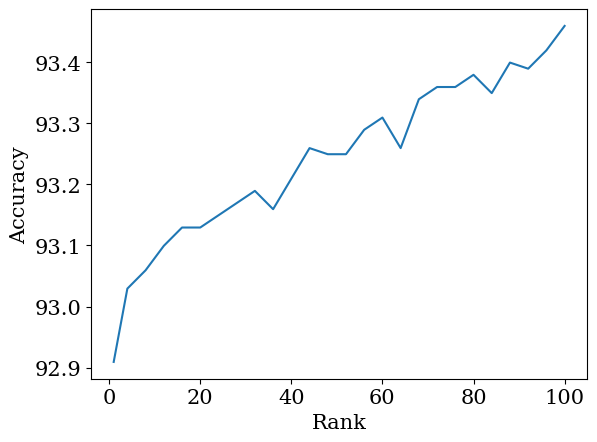

In [ ]:
# plot accuracy and rank
import matplotlib.pyplot as plt
ranksize = [i for i in range(0, 101, 4)]
ranksize[0] = 1

plt.rcParams.update({'font.size': 15})
plt.rcParams['font.family'] = 'serif'
plt.plot(ranksize, accuracy)
plt.xlabel('Rank')
plt.ylabel('Accuracy')
plt.savefig('accuracy.png', dpi=300)
plt.show()

## Interpretation

The saved run shows a modest accuracy increase across ranks. Fresh biases, shared weights, no fixed seed or repeated trials, and an extra training epoch for adapters limit conclusions about rank alone. The experiment does not isolate why the GPT-2 variant behaved differently.
